In [1]:
############################################################################################################################
######     Plotting for figure 2,3,4 and the supplementary                                                        ##########
############################################################################################################################
# import modules
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp
tfd = tfp.distributions
tfb = tfp.bijectors

import matplotlib.ticker as tick
plt.style.use('ggplot') 
plt.style.use('seaborn-paper') 
plt.style.use('seaborn-whitegrid') 

np.set_printoptions(suppress=True)

In [2]:
# Load data
dat=pd.read_csv("Z_score.csv")

In [3]:
# Sort the values
dat=dat.sort_values(by=["Z_score"])

#Rank from the lowest to highest
dat["Rank"]=np.arange(1,241,1)

# Calculate the percentiles
dat["Percentiles"]=(dat["Rank"]-0.5)/240

# Calculate theoretical quantiles
dat["Theoretical_Z"]=stats.norm.ppf(dat["Percentiles"])

# Calculate Sample quantiles
dat["Sample_Z"]=(dat["Z_score"]-np.mean(dat["Z_score"]))/np.std(dat["Z_score"])

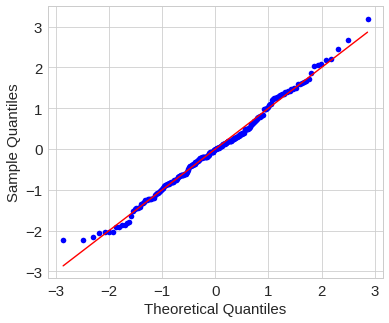

In [7]:
# Plotting QQ-plot
fig=plt.figure(figsize=(6,5))
plt.plot(dat["Theoretical_Z"],dat["Sample_Z"],"o",color="blue")
plt.plot(dat["Theoretical_Z"],dat["Theoretical_Z"]*1 + 0,color="r")
plt.xlabel("Theoretical Quantiles",fontsize=15)
plt.ylabel("Sample Quantiles",fontsize=15)
plt.tick_params(axis='both', which='major', labelsize=15)
#plt.title("C)",fontsize=15)
#plt.savefig("QQ-plot.png",dpi=300)
plt.show()

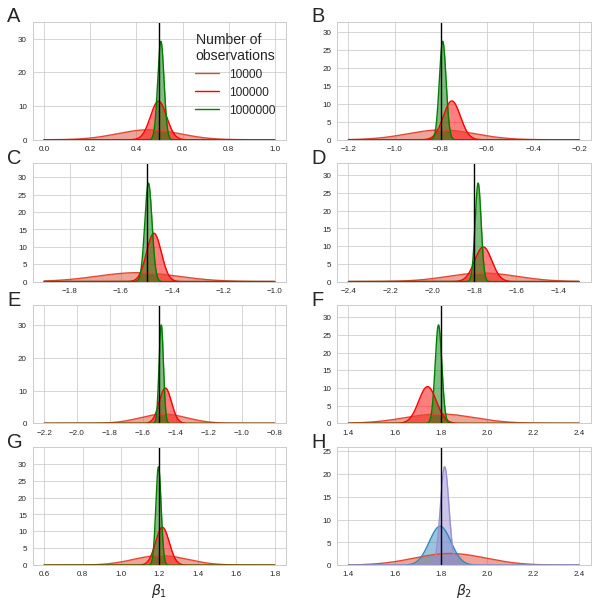

In [9]:
# Plotting probability density of 10000,100000,1000000


# Positive-Negative coefficients
x = np.arange(0,1.0,0.001)
PPK= tfp.distributions.Normal(loc=0.4523672,scale=0.13515954).prob(x)
PPL = tfp.distributions.Normal(loc=0.49568135,scale=0.03478395).prob(x)
PPM = tfp.distributions.Normal(loc=0.50597334,scale=0.01365028).prob(x)

fig,ax=plt.subplots(4,2, figsize=(10,10))
ax[0][0].plot(x,PPK,c='C0')
ax[0][0].plot(x,PPL,c='red')
ax[0][0].plot(x,PPM,c='green')
ax[0][0].fill_between(x,PPK,color='C0',alpha=0.5)
ax[0][0].fill_between(x,PPL,color='red',alpha=0.5)
ax[0][0].fill_between(x,PPM,color='green',alpha=0.5)
ax[0][0].axvline(0.5,c='black')
ax[0][0].set_ylim(0,PPM.numpy().max()*1.2)
#ax[0][0].set_xlabel(r"$\beta_1$",fontsize=14)
ax[0][0].text(-0.1,1,'A', size=20, transform=ax[0][0].transAxes)
ax[0][0].legend(loc="best",labels=["10000","100000","1000000"],title="Number of\nobservations",
             fontsize=12,title_fontsize=14)

x = np.arange(-1.2,-0.2,0.001)
PPK1= tfp.distributions.Normal(loc=-0.79752296,scale=0.14592543).prob(x)
PPL1= tfp.distributions.Normal(loc=-0.75204116,scale=0.03698448).prob(x)
PPM1= tfp.distributions.Normal(loc=-0.7916548,scale=0.01457316).prob(x)
ax[0][1].plot(x,PPK1,c='C0')
ax[0][1].plot(x,PPL1,c='red')
ax[0][1].plot(x,PPM1,c='green')
ax[0][1].fill_between(x,PPK1,color='C0',alpha=0.5)
ax[0][1].fill_between(x,PPL1,color='red',alpha=0.5)
ax[0][1].fill_between(x,PPM1,color='green',alpha=0.5)
ax[0][1].axvline(-0.8,c='black')
ax[0][1].set_ylim(0,PPM1.numpy().max()*1.2)
#ax[0][1].set_xlabel(r"$\beta_2$", fontsize=14)
ax[0][1].text(-0.1,1,'B', size=20, transform=ax[0][1].transAxes)


# Negative-Negative coefficients
x = np.arange(-1.9,-1.0,0.001)
NNK= tfp.distributions.Normal(loc=-1.536537,scale=0.15595654).prob(x)
NNL = tfp.distributions.Normal(loc=-1.4717115,scale=0.02870001).prob(x)
NNM = tfp.distributions.Normal(loc=-1.4932564,scale=0.01407821).prob(x)

ax[1][0].plot(x,NNK,c='C0')
ax[1][0].plot(x,NNL,c='red')
ax[1][0].plot(x,NNM,c='green')
ax[1][0].fill_between(x,NNK,color='C0',alpha=0.5)
ax[1][0].fill_between(x,NNL,color='red',alpha=0.5)
ax[1][0].fill_between(x,NNM,color='green',alpha=0.5)
ax[1][0].axvline(-1.5,c='black')
ax[1][0].set_ylim(0,NNM.numpy().max()*1.2)
#ax[1][0].set_xlabel(r"$\beta_1$",fontsize=14)
ax[1][0].text(-0.1,1,'C', size=20, transform=ax[1][0].transAxes)
#ax[1][0].legend(loc="best",labels=["10000","100000","1000000"],title="Observations",
             #fontsize=14,title_fontsize=16)

x = np.arange(-2.4,-1.3,0.001)
NNK1= tfp.distributions.Normal(loc=-1.7603903,scale=0.16576165).prob(x)
NNL1= tfp.distributions.Normal(loc=-1.757564,scale=0.04073759).prob(x)
NNM1= tfp.distributions.Normal(loc=-1.7819358,scale=0.01434045).prob(x)

ax[1][1].plot(x,NNK1,c='C0')
ax[1][1].plot(x,NNL1,c='red')
ax[1][1].plot(x,NNM1,c='green')
ax[1][1].fill_between(x,NNK1,color='C0',alpha=0.5)
ax[1][1].fill_between(x,NNL1,color='red',alpha=0.5)
ax[1][1].fill_between(x,NNM1,color='green',alpha=0.5)
ax[1][1].axvline(-1.8,c='black')
ax[1][1].set_ylim(0,NNM1.numpy().max()*1.2)
#ax[1][1].set_xlabel(r"$\beta_2$", fontsize=14)
ax[1][1].text(-0.1,1,'D', size=20, transform=ax[1][1].transAxes)

# Negative-positive coefficients
x = np.arange(-2.2,-0.8,0.001)
NPK= tfp.distributions.Normal(loc=-1.4757782,scale=0.14176352).prob(x)
NPL = tfp.distributions.Normal(loc=-1.4643744,scale=0.03710392).prob(x)
NPM = tfp.distributions.Normal(loc=-1.4891123,scale=0.01332322).prob(x)
ax[2][0].plot(x,NPK,c='C0')
ax[2][0].plot(x,NPL,c='red')
ax[2][0].plot(x,NPM,c='green')
ax[2][0].fill_between(x,NPK,color='C0',alpha=0.5)
ax[2][0].fill_between(x,NPL,color='red',alpha=0.5)
ax[2][0].fill_between(x,NPM,color='green',alpha=0.5)
ax[2][0].axvline(-1.5,c='black')
ax[2][0].set_ylim(0,NPM.numpy().max()*1.2)
#ax[2][0].set_xlabel(r"$\beta_1$",fontsize=14)
ax[2][0].text(-0.1,1,'E', size=20, transform=ax[2][0].transAxes)
#ax[1][0].legend(loc="upper right",labels=["10000","100000","1000000"],title="Observations",
             #fontsize=14,title_fontsize=16)

x = np.arange(1.4,2.4,0.001)
NPK1= tfp.distributions.Normal(loc=1.7954538,scale=0.15046774).prob(x)
NPL1= tfp.distributions.Normal(loc=1.7426754,scale=0.03841416).prob(x)
NPM1= tfp.distributions.Normal(loc=1.790077,scale=0.01433117).prob(x)

ax[2][1].plot(x,NPK1,c='C0')
ax[2][1].plot(x,NPL1,c='red')
ax[2][1].plot(x,NPM1,c='green')
ax[2][1].fill_between(x,NPK1,color='C0',alpha=0.5)
ax[2][1].fill_between(x,NPL1,color='red',alpha=0.5)
ax[2][1].fill_between(x,NPM1,color='green',alpha=0.5)
ax[2][1].axvline(1.8,c='black')
ax[2][1].set_ylim(0,NPM1.numpy().max()*1.2)
#ax[2][1].set_xlabel(r"$\beta_2$", fontsize=14)
ax[2][1].text(-0.1,1,'F', size=20, transform=ax[2][1].transAxes)


# Positive-Positive coefficients
x = np.arange(0.6,1.8,0.001)
PPK= tfp.distributions.Normal(loc=1.2062879,scale=0.14018877).prob(x)
PPL = tfp.distributions.Normal(loc=1.2156487,scale=0.03553431).prob(x)
PPM = tfp.distributions.Normal(loc=1.195252,scale=0.0136965).prob(x)
ax[3][0].plot(x,PPK,c='C0')
ax[3][0].plot(x,PPL,c='red')
ax[3][0].plot(x,PPM,c='green')
ax[3][0].fill_between(x,PPK,color='C0',alpha=0.5)
ax[3][0].fill_between(x,PPL,color='red',alpha=0.5)
ax[3][0].fill_between(x,PPM,color='green',alpha=0.5)
ax[3][0].axvline(1.2,c='black')
ax[3][0].set_ylim(0,PPM.numpy().max()*1.2)
ax[3][0].set_xlabel(r"$\beta_1$",fontsize=14)
ax[3][0].text(-0.1,1,'G', size=20, transform=ax[3][0].transAxes)
#ax[2][0].legend(loc="upper right",labels=["10000","100000","1000000"],title="Observations",
             #fontsize=14,title_fontsize=16)

x = np.arange(1.4,2.4,0.001)
PPK1= tfp.distributions.Normal(loc=1.83986,scale=0.15522479).prob(x)
PPL1= tfp.distributions.Normal(loc=1.7971259,scale=0.04666927).prob(x)
PPM1= tfp.distributions.Normal(loc=1.8167716,scale=0.01844882).prob(x)

ax[3][1].plot(x,PPK1,c='C0')
ax[3][1].plot(x,PPL1,c='C1')
ax[3][1].plot(x,PPM1,c='C2')
ax[3][1].fill_between(x,PPK1,color='C0',alpha=0.5)
ax[3][1].fill_between(x,PPL1,color='C1',alpha=0.5)
ax[3][1].fill_between(x,PPM1,color='C2',alpha=0.5)
ax[3][1].axvline(1.8,c='black')
ax[3][1].set_ylim(0,PPM1.numpy().max()*1.2)
ax[3][1].set_xlabel(r"$\beta_2$", fontsize=14)
ax[3][1].text(-0.1,1,'H', size=20, transform=ax[3][1].transAxes)

plt.savefig('Figure_2.png',dpi=300)
plt.savefig('Figure_2.pdf',dpi=300)
plt.show()

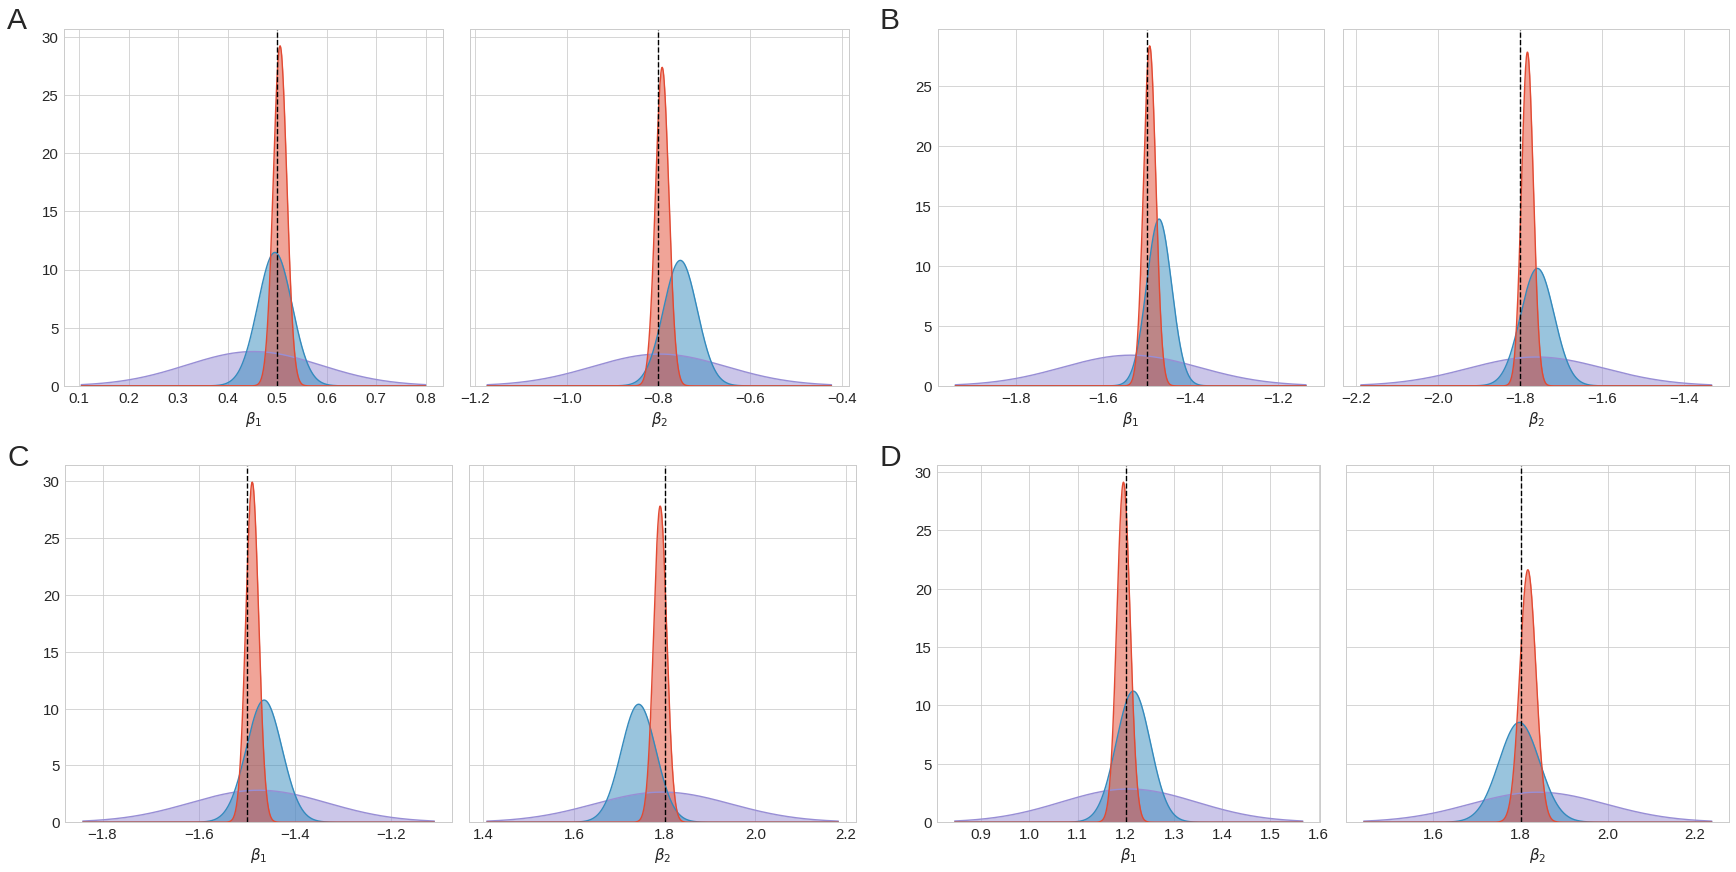

In [65]:
import matplotlib.pyplot as plt

fig = plt.figure(constrained_layout=True,figsize=(24,10))
subfigs = fig.subfigures(2, 2)

mean_values = np.array([[[0.4523672,0.49568135,0.50597334],[-0.79752296,-0.75204116,-0.7916548]],
                        [[-1.536537,-1.4717115,-1.4932564],[-1.7603903,-1.757564,-1.7819358]],
                        [[-1.4757782,-1.4643744,-1.4891123],[1.7954538,1.7426754,1.790077]],
                        [[1.2062879,1.2156487,1.195252],[1.83986,1.7971259,1.8167716]]])

std_values = np.array([[[0.13515954,0.03478395,0.01365028],[0.14592543,0.03698448,0.01457316]],
                        [[0.15595654,0.02870001,0.01407821],[0.16576165,0.04073759,0.01434045]],
                        [[0.14176352,0.03710392,0.01332322],[0.15046774,0.03841416,0.01433117]],
                        [[0.14018877,0.03553431,0.0136965],[0.15522479,0.04666927,0.01844882]]])

true_values = np.array([[0.5,-0.8],[-1.5,-1.8],[-1.5,1.8],[1.2,1.8]])

labels = ['A','B','C','D']
colors = ['C2','C1','C0']
xlabels = [r"$\beta_1$", r"$\beta_2$"]

for outerind, subfig in enumerate(subfigs.flat):
    axs = subfig.subplots(1, 2,sharey=True)
    
    axs[0].text(-0.15,1,labels[outerind], size=30, transform=axs[0].transAxes)
    
    panel_means = mean_values[outerind]
    panel_std = std_values[outerind]
    
    for i in range(2):
        xmin = panel_means[i][0] - 2.576* panel_std[i][0]
        xmax = panel_means[i][0] + 2.576* panel_std[i][0]

    
        # Positive-Negative coefficients
        x = np.arange(xmin,xmax,0.001)
        
        for j in range(3):
            dist = tfp.distributions.Normal(loc=panel_means[i,j],scale=panel_std[i,j]).prob(x)
        
            axs[i].plot(x,dist,c=colors[j])
            axs[i].fill_between(x,dist,color=colors[j],alpha=0.5)
        axs[i].axvline(true_values[outerind,i],c='black',ls='--')
        axs[i].set_ylim(0,None)#PPM.numpy().max()*1.05)
        axs[i].tick_params(axis='both', which='major', labelsize=15)
        axs[i].set_xlabel(xlabels[i],fontsize=15)

plt.savefig('Figure_2_CT.png',dpi=300)

plt.show()

In [51]:

mean_values.shape

(4, 2, 3)

In [ ]:
import matplotlib.pyplot as plt

fig = plt.figure(constrained_layout=True)

subfigs = fig.subfigures(2, 2)

for outerind, subfig in enumerate(subfigs.flat):
    subfig.suptitle(f'Subfig {outerind}')
    axs = subfig.subplots(2, 1)
    for innerind, ax in enumerate(axs.flat):
        ax.set_title(f'outer={outerind}, inner={innerind}', fontsize='small')
        ax.set_xticks([])
        ax.set_yticks([])
 
plt.show()

2023-03-07 14:07:58.587879: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-03-07 14:07:59.069181: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1510] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 263 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0001:00:00.0, compute capability: 7.5


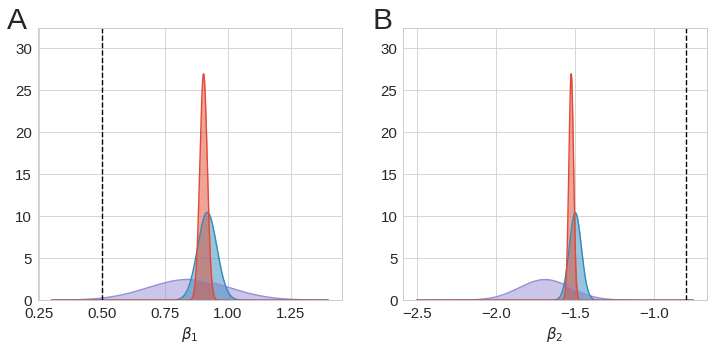

In [5]:
# Plotting probability density of 10000,100000,1000000 for step selection model without midpoints
x = np.arange(0.3,1.4,0.001)
sK= tfp.distributions.Normal(loc=0.84529182,scale=0.16132132).prob(x)
sL = tfp.distributions.Normal(loc=0.9187723,scale=0.03811273).prob(x)
sM = tfp.distributions.Normal(loc=0.9040976,scale=0.01479852).prob(x)

fig,ax=plt.subplots(1,2, figsize=(12,5))
ax[0].plot(x,sK,c='C2')
ax[0].plot(x,sL,c='C1')
ax[0].plot(x,sM,c='C0')
ax[0].fill_between(x,sK,color='C2',alpha=0.5)
ax[0].fill_between(x,sL,color='C1',alpha=0.5)
ax[0].fill_between(x,sM,color='C0',alpha=0.5)
ax[0].axvline(0.5,c='black',ls='--')
ax[0].set_ylim(0,sM.numpy().max()*1.2)
ax[0].set_xlabel(r"$\beta_1$",fontsize=15)
ax[0].text(-0.1,1,'A', size=30, transform=ax[0].transAxes)
ax[0].tick_params(axis='both', which='major', labelsize=15)
#ax[0].legend(loc="upper right",labels=["10000","100000","1000000"],title="Observations",
             #fontsize=14,title_fontsize=16)

x = np.arange(-2.5,-0.75,0.001)
sK1= tfp.distributions.Normal(loc=-1.689274,scale=0.16246870).prob(x)
sL1= tfp.distributions.Normal(loc=-1.497402,scale=0.03827346).prob(x)
sM1= tfp.distributions.Normal(loc=-1.523381,scale=0.01479742).prob(x)

ax[1].plot(x,sK1,c='C2')
ax[1].plot(x,sL1,c='C1')
ax[1].plot(x,sM1,c='C0')
ax[1].fill_between(x,sK1,color='C2',alpha=0.5)
ax[1].fill_between(x,sL1,color='C1',alpha=0.5)
ax[1].fill_between(x,sM1,color='C0',alpha=0.5)
ax[1].axvline(-0.8,c='black',ls='--')
ax[1].set_ylim(0,sM1.numpy().max()*1.2)
ax[1].set_xlabel(r"$\beta_2$", fontsize=15)
ax[1].text(-0.1,1,'B', size=30, transform=ax[1].transAxes)
ax[1].tick_params(axis='both', which='major', labelsize=15)
plt.savefig('MSSF.png')
plt.show()